In [189]:
import numpy as np
import matplotlib.pyplot as plt

import gepy
import pygimli as pg

import plots as plots

In [182]:
#%%___General parameters_______________________________________

#_____Coordinates______________________________________________

# like profile coord, but take x0,x1 and y0,y1 of area, area width/length should be divisible by 10000
# area_coords = [1300000,1400000,-275000,-375000] # Lake Vostok "south-western" edge
# profile_coord=([1300000,1400000],[-320000,-300000]) # LV prof 1
# profile_coord=([1300000,1400000],[-340000,-320000]) # LV prof 2
# profile_coord=([1325000,1365000],[-275000,-375000]) # LV prof 3

area_coords = [1355000,1435000,-855000,-985000] # Dome C
# profile_coord=([1405000,1435000],[-985000,-855000]) # DC prof 1
# profile_coord=([1360000,1415000],[-985000,-855000]) # DC prof 2
profile_coord=([1355000,1420000],[-920000,-985000]) # DC prof 3
# profile_coord=([1355000,1435000],[-905000,-970000]) # DC prof 3
# 
# area_coords = [1800000,1900000,-650000,-750000] # ASB
# profile_coord=([1900000,1800000],[-650000,-750000]) # ASB prof 1
# profile_coord=([1800000,1900000],[-750000,-650000]) # ASB prof 1
# profile_coord=([1800000,1900000],[-700000,-700000]) # ASB prof 2

#_____Set layers & thermal parameters__________________________

layers = 4
do_sediments = True
do_hp = 'REF' # REF, CONST, NONE

k0 = 1.5    # sediment layer
k1 = 2.7    # crust
k2 = 3.5    # mantle 

hp_0 = 0.000001

#_____Data Input_______________________________________________

data_input = []

data_input.append(np.load("data_example/topography.npz"))
data_input.append(np.load("data_example/Sediments.npz"))
data_input.append(np.load("data_example/Moho.npz"))
data_input.append(np.load("data_example/LAB.npz"))
data_input.append(np.load("data_example/HP.npz"))

data_resolution = [1000,9250,10000,10000,25500]
# data_resolution = [1000,9250,10000,10000,25500]

#_____

tc = [k0,k1,k2]

if do_hp == 'NONE':
    hp_0 = None
elif do_hp == 'CONST':
    hp_0 = hp_0
    data_input.append('CONST')

In [183]:
#%%___cut data to size & interpolate along profile and region__

#___2D___

data_list_2D = []
for i,layer in enumerate(data_input):
    coord,data = gepy.cut_and_interpolate_2d(layer, data_resolution, i, layers, area_coords, profile_coord,
                                        do_sediments=do_sediments, do_hp=do_hp, hp_0=hp_0)
    data_list_2D.append([coord,data])

# in case sediment layer input is 'thickness': subtract it from topography for a depth
if do_sediments:
    data_list_2D[1][1] = data_list_2D[0][1]-data_list_2D[1][1]

#___3D___

data_list_3D = []
for i,layer in enumerate(data_input):
    x,y,data = gepy.cut_and_interpolate_3d(layer, data_resolution, i, layers, area_coords,
                                        do_sediments=do_sediments, do_hp=do_hp, hp_0=hp_0)
    data_list_3D.append([x,y,data])

In [184]:
#%%___build the world__________________________________________

#___2D___
mesh_2D,line_list_2D = gepy.build_world_2d(data_list_2D, profile_coord, area=None,
                                      layers=layers, do_sediments=do_sediments)

#___3D___
mesh_3D,layer_list_3D = gepy.build_world_3d(data_list_3D, area_coords, area=None, # 2.5
                                      layers=layers, do_sediments=do_sediments, border = 10)

In [185]:
#%%___apply correct markers to cells and nodes_________________

#___2D___
mesh_2D,force_2D = gepy.assign_markers_2d(data_list_2D, mesh_2D, layers=layers, 
                                          do_sediments=do_sediments, do_hp=do_hp, hp_0=hp_0, tc=tc)

#___3D___
mesh_3D,force_3D = gepy.assign_markers_3d(data_list_3D, mesh_3D, layers=layers, 
                                          do_sediments=do_sediments, do_hp=do_hp, hp_0=hp_0, tc=tc)

In [186]:
#%%___run calc and get shf_____________________________________

#___2D___
T_2D = gepy.calc_temp(mesh_2D, "2D", layers, force=force_2D, do_sediments=do_sediments, do_hp=do_hp, tc=tc)
ghf_2D = gepy.calc_ghf(T_2D, mesh_2D, data_list_2D, "2D", tc)

#___3D___
T_3D = gepy.calc_temp(mesh_3D, "3D", layers, force=force_3D, do_sediments=do_sediments, do_hp=do_hp, tc=tc)
ghf_3D = gepy.calc_ghf(T_3D, mesh_3D, data_list_3D, "3D", tc)

Mesh:  Mesh: Nodes: 65077 Cells: 129244 Boundaries: 194320
Assembling time:  1.2444794
Solving time:  0.5930832
Mesh:  Mesh: Nodes: 90104 Cells: 394646 Boundaries: 828847
Assembling time:  20.2196627
Solving time:  1.2629443


In [ ]:
#%%___visualize results________________________________________

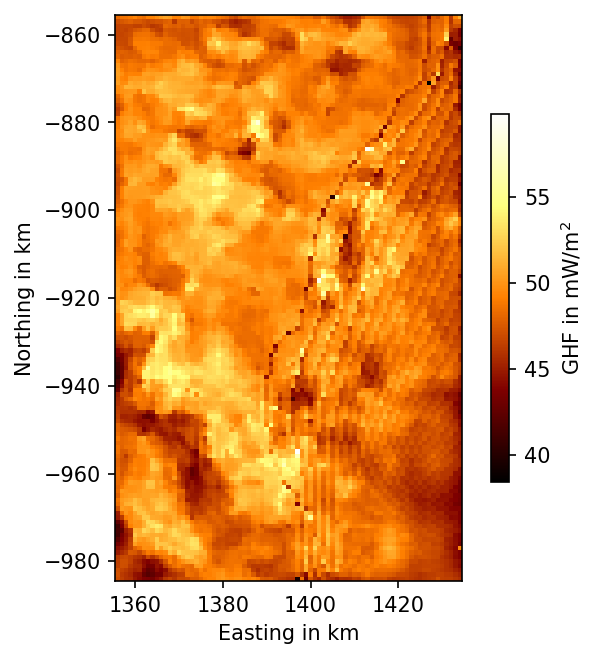

In [191]:
#___results 3D___
plots.plot_3D(data_list_3D,ghf_3D)

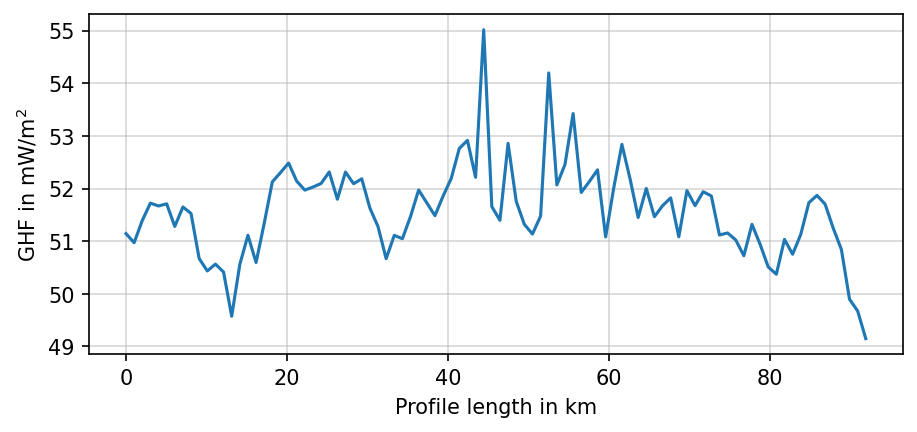

In [193]:
#___results 2D___
plots.plot_2D(data_list_2D,ghf_2D)

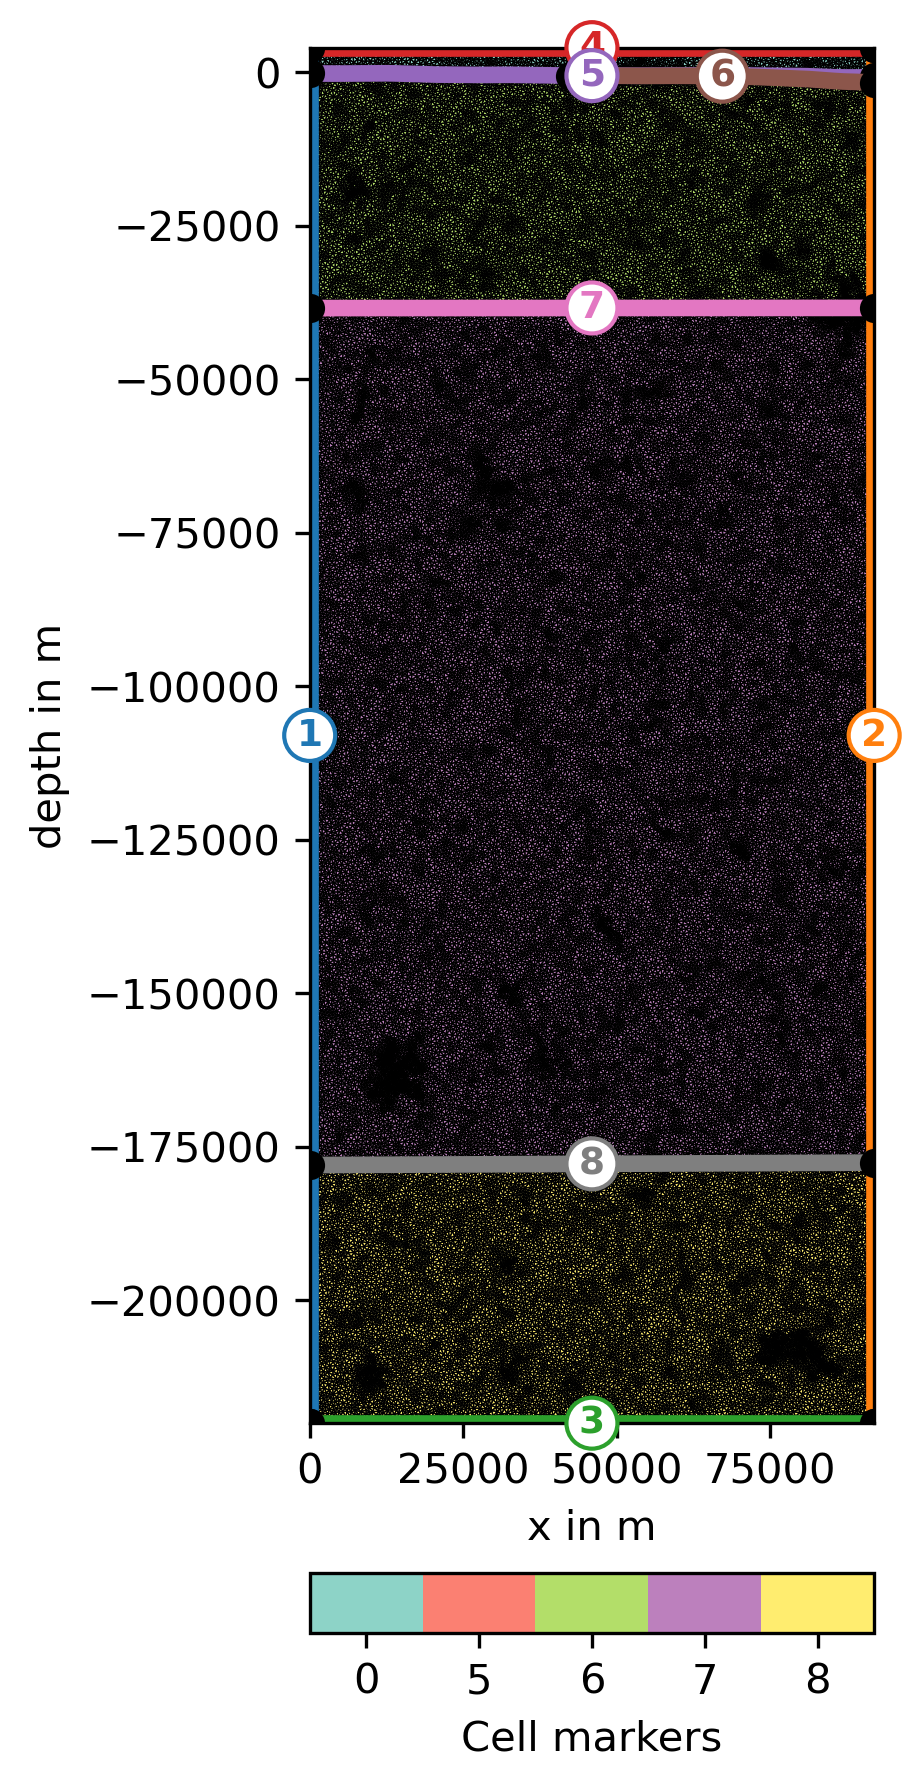

In [195]:
#___mesh 2D___
plots.plot_2D_mesh(mesh_2D,T=False)

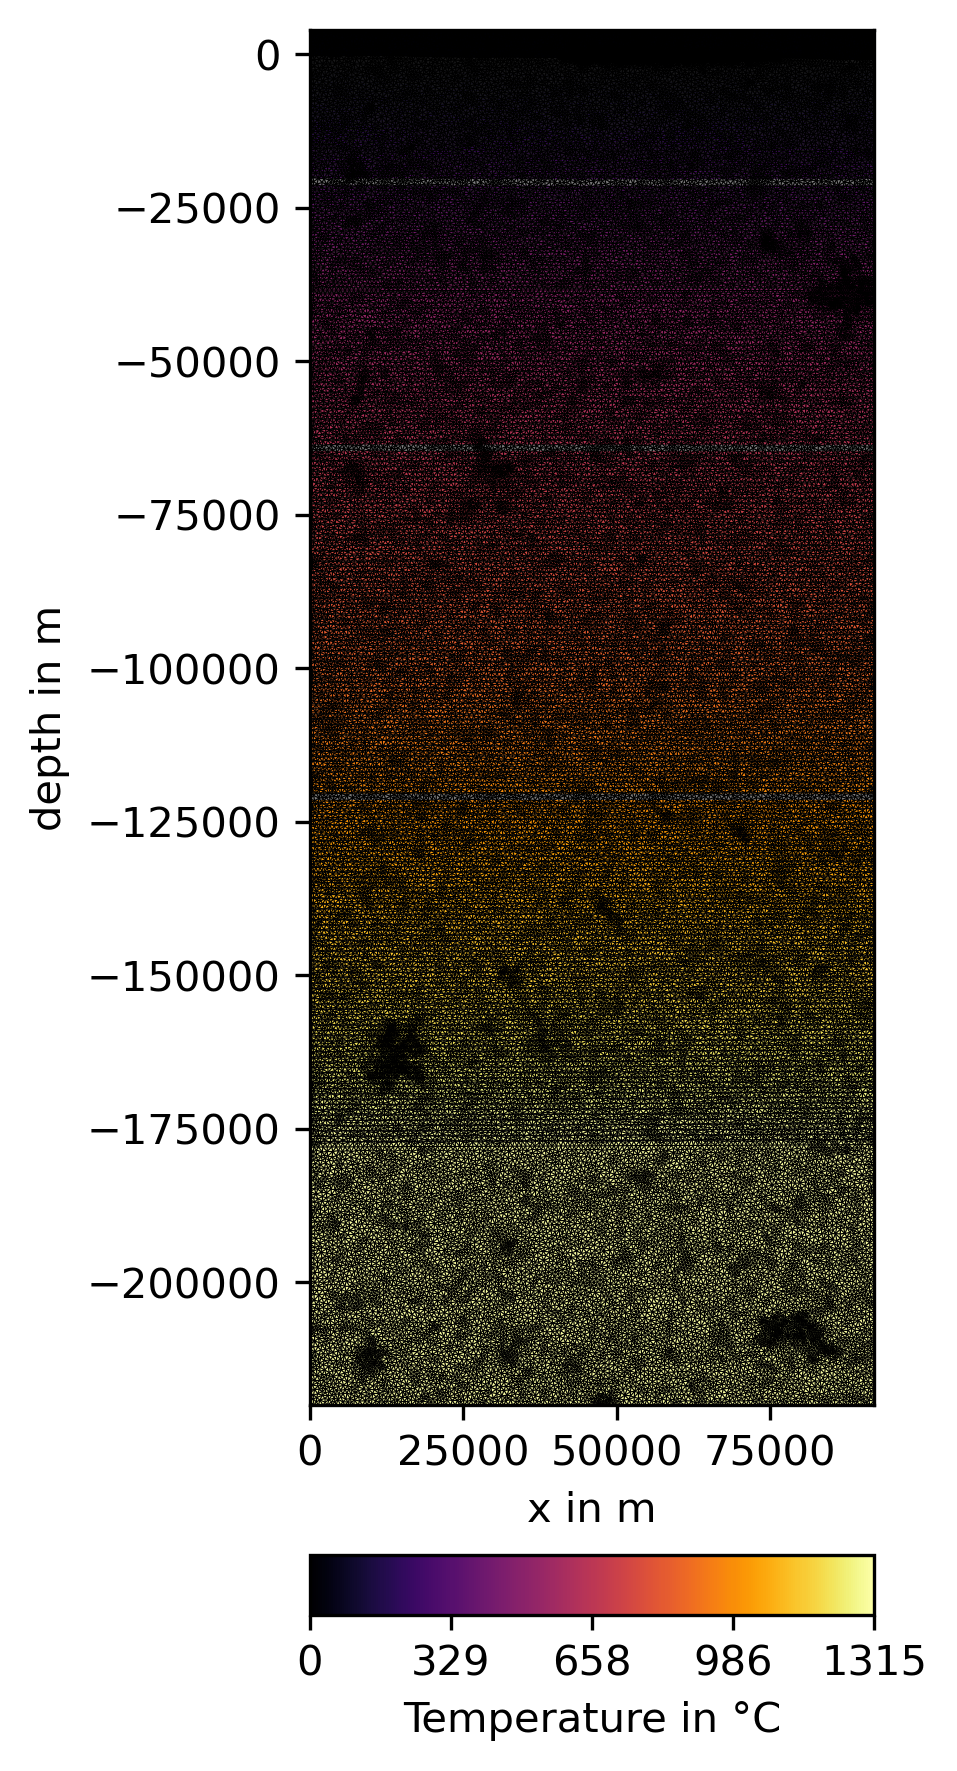

In [199]:
#___mesh 2D with emperature___
plots.plot_2D_mesh(mesh_2D,T=T_2D)

In [197]:
#___mesh 3D___
plots.plot_3D_mesh(mesh_3D,T=False)

In [200]:
#___mesh 3D with emperature___
plots.plot_3D_mesh(mesh_3D,T=T_3D)